# Project Objective

- Develop an end-to-end Machine Learning solution for defect detection in hot rolling processes.
- Accurately identify defective products using classification models.
- Minimize missed defects (False Negatives).
- Improve defect detection performance through model optimization and evaluation.
- Select the best-performing model based on business requirements.

# Techniques Used

- Object-Oriented Programming (OOP) based pipeline design
- Data Loading and Data Validation
- Exploratory Data Analysis (EDA)
- Missing Value Handling
- Feature Engineering
- Correlation Analysis
- Train-Validation Split
- Class Imbalance Handling
  - `class_weight='balanced'`
  - `scale_pos_weight`
- Logistic Regression
- XGBoost Classifier
- Hyperparameter Tuning using RandomizedSearchCV
- Probability-Based Predictions
- Model Evaluation using:
  - Accuracy
  - Precision
  - Recall
  - F1-Score
  - ROC-AUC Score
  - Confusion Matrix
- Model Comparison and Selection
- Model Serialization using Pickle (`.pkl`)

# Success Criteria

- Maximize Recall for the Defect Class (Class 1)
- Minimize False Negatives (Missed Defects)
- Maintain acceptable Precision and Overall Model Performance
- Select the best-performing model based on business requirements

# Final Model Selection

- Logistic Regression was selected as the final model.
- Achieved a Recall Score of **92.31%** for the defect class.
- Correctly identified **12 out of 13 defective products**.
- Missed only **1 defective sample**.
- Demonstrated superior defect detection capability compared to XGBoost models.
- Suitable for business scenarios where missing a defect is more costly than investigating false alarms.

In [10]:
# creating class for Data loading
import pandas as pd

class DataLoader:

    def __init__(self, train_path, test_path, sample_path):
        self.train_path = train_path
        self.test_path = test_path
        self.sample_path = sample_path


    def load_data(self):
        self.train_df = pd.read_csv(self.train_path)
        self.test_df = pd.read_csv(self.test_path)
        self.sample_df = pd.read_csv(self.sample_path)

        return self # returning the entire object

In [11]:
# creating object
data = DataLoader(r'C:\Users\LENOVO\OneDrive\Desktop\Machine learning\Defect Detection in Hot rolling\169df72b552611f1\dataset\train.csv',
                  r'C:\Users\LENOVO\OneDrive\Desktop\Machine learning\Defect Detection in Hot rolling\169df72b552611f1\dataset\test.csv',
                  r'C:\Users\LENOVO\OneDrive\Desktop\Machine learning\Defect Detection in Hot rolling\169df72b552611f1\dataset\sample_submission.csv')

data.load_data()
data.train_df.head()

,CoilID,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X41,X42,X43,X44,X45,X46,X47,X48,X49,Y
0,487,854.787195,501.088868,414.841484,710.583316,662.072013,656.076977,547.040479,563.653582,495.296785,...,0.201645,0.047960,0.267467,0.052247,-0.893174,0.000000,0.028925,0.000534,0.010797,0.0
1,44,1056.526699,868.083321,622.879982,725.276469,665.235554,647.450550,552.333202,565.105074,493.310075,...,0.644403,0.000000,0.341870,0.153513,25.471899,0.002520,0.033281,0.028349,0.079602,0.0
2,192,1095.648362,668.112517,695.787904,716.773671,662.843475,657.542380,549.863867,546.210823,482.814753,...,0.486502,0.000000,0.202539,0.168192,-25.764196,0.002072,0.033878,0.000000,0.058266,0.0
3,1552,1050.943543,660.340015,440.280245,611.562496,628.081103,561.397721,456.816210,550.103433,378.353283,...,1.198010,0.020787,0.288786,0.329108,1.033840,0.000250,0.045490,0.039004,0.004850,0.0
4,1190,1091.640314,297.363775,842.665620,749.160886,652.992309,615.576656,608.364764,549.756758,487.753140,...,0.237231,0.000841,0.257281,0.112637,-11.130157,0.002376,0.031298,0.003623,0.018434,0.0


In [49]:
# Creating class for data validation
class DataInspector:
    
    def __init__(self):
        """
        Stores the data frame
        
        """
        self.df = data.train_df
        
       
    def shape(self):
        """
        Display the dataset shape (rows, columns).
        """
        print('Shape:', self.df.shape)
        return self


    def columns(self):
        """
        Display all column names in the dataset.
        """
        print(self.df.columns.tolist())
        return self


    def info(self):
        """
        Display data types, non-null counts, and memory usage.
        """
        print(self.df.info())
        return self


    def missing_values(self):
        """
        Display the number of missing values in each column.
        """
        print(self.df.isnull().sum())
        return self


    def duplicates(self):
        """
        Display the number of duplicate rows in the dataset.
        """
        print('Duplicate rows:', self.df.duplicated().sum())
        return self


    def summary_stats(self):
        """
        Display descriptive statistics for numerical columns.
        """
        print(self.df.describe())
        return self


    def target_distribution(self):
        """
        Display the class distribution of the target variable.
    
        Parameters
        ----------
        target : str
        Name of the target column. Default is 'Y'.
        """
        print(self.df['Y'].value_counts())
        return self


In [50]:
# creating object
inspector = DataInspector()
# method chaining
inspector.shape().columns().info().missing_values().duplicates().summary_stats().target_distribution()

Shape: (1352, 51)
['CoilID', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23', 'X24', 'X25', 'X26', 'X27', 'X28', 'X29', 'X30', 'X31', 'X32', 'X33', 'X34', 'X35', 'X36', 'X37', 'X38', 'X39', 'X40', 'X41', 'X42', 'X43', 'X44', 'X45', 'X46', 'X47', 'X48', 'X49', 'Y']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1352 entries, 0 to 1351
Data columns (total 51 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   CoilID  1352 non-null   int64  
 1   X1      1352 non-null   float64
 2   X2      1352 non-null   float64
 3   X3      1352 non-null   float64
 4   X4      1352 non-null   float64
 5   X5      1352 non-null   float64
 6   X6      1352 non-null   float64
 7   X7      1352 non-null   float64
 8   X8      1351 non-null   float64
 9   X9      1352 non-null   float64
 10  X10     1346 non-null   float64
 11  X11     1352 non-null   float64
 12  X1

### Initial Data Inspection Summary

* The dataset contains **1,352 observations/rows** and **51 columns/features**, consisting of 49 process variables (X1–X49), one identifier column (CoilID), and the target variable (Y).
* Several features contain missing values, with **X15 (160 missing values)** showing the highest level of missingness, followed by X42 (31 missing values) and X48 (13 missing values). Appropriate imputation techniques will be required before model training.
* No duplicate records were found in the dataset, indicating good data quality and reducing the risk of biased model learning.
* The target variable is highly imbalanced, with **1,286 non-defective coils (95.1%)** and **66 defective coils (4.9%)**. This class imbalance may affect model performance and requires special handling through techniques such as class weighting or imbalance-aware algorithms.
* Most predictor variables are continuous numerical features, making them suitable for statistical analysis, correlation analysis, and machine learning algorithms such as Logistic Regression and XGBoost.

### Key Implications

* Missing value treatment will be an important preprocessing step.
* Class imbalance is a major challenge and should be considered during model development and evaluation.
* Accuracy alone may be misleading due to the skewed class distribution; Precision, Recall, F1-Score, and ROC-AUC should be emphasized.


In [90]:
# creating class for Exploratory Data Analysis (EDA)
import matplotlib.pyplot as plt
import seaborn as sns

class EDAAnalyzer:

    def __init__(self):
        """
        Initialize EDA class with the training dataset.
        """
        self.df = data.train_df

    def plot_target_distribution(self):
        """
        Visualize the distribution of the target variable (Y).
        Helps identify class imbalance between defective and non-defective products.
        """
        sns.countplot(x='Y', data=self.df)
        plt.title('Target Distribution')
        plt.show()
        return self

    def plot_histograms(self):
        """
        Plot histograms for all numerical features.
        Helps understand feature distributions, skewness, and data spread.
        """
        self.df.drop(columns=['Y']).hist(figsize=(20,20))
        plt.tight_layout()
        plt.show()
        return self

    def plot_boxplots(self):
        """
        Plot boxplots for all numerical features.
        Helps detect outliers and understand feature variability.
        """
        self.df.drop(columns=['Y']).plot(kind='box', subplots=True, layout=(10,5), figsize=(20,25))
        plt.tight_layout()
        plt.show()
        return self

    def correlation_heatmap(self):
        """
        Display correlation heatmap of numerical features.
        Helps identify highly correlated variables and potential multicollinearity.
        """
        plt.figure(figsize=(10,8))
        sns.heatmap(self.df.drop(columns=['CoilID']).corr(),cmap='coolwarm')
        plt.show()
        return self

    def compare_feature_by_target(self, feature):
        """
        Compare a selected feature across target classes using a boxplot.

        Parameters
        ----------
        feature : str
            Feature name to compare against the target variable.
        """
        sns.boxplot(x='Y', y=feature, data=self.df)
        plt.show()
        return self

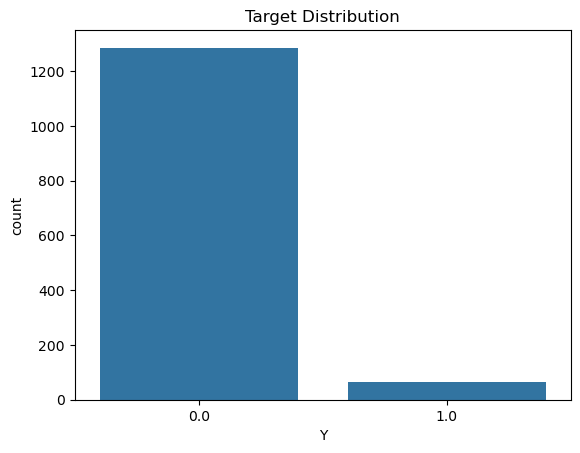

In [91]:
# creatinf object
eda = EDAAnalyzer()
eda.plot_target_distribution()

# Target Variable Analysis
Key Observations
The target variable (Y) is highly imbalanced.
Class 0 (Non-Defective Coil) contains approximately 1,286 observations (95.1%).
Class 1 (Defective Coil) contains only 66 observations (4.9%).
The large difference between the two classes indicates a significant class imbalance problem.

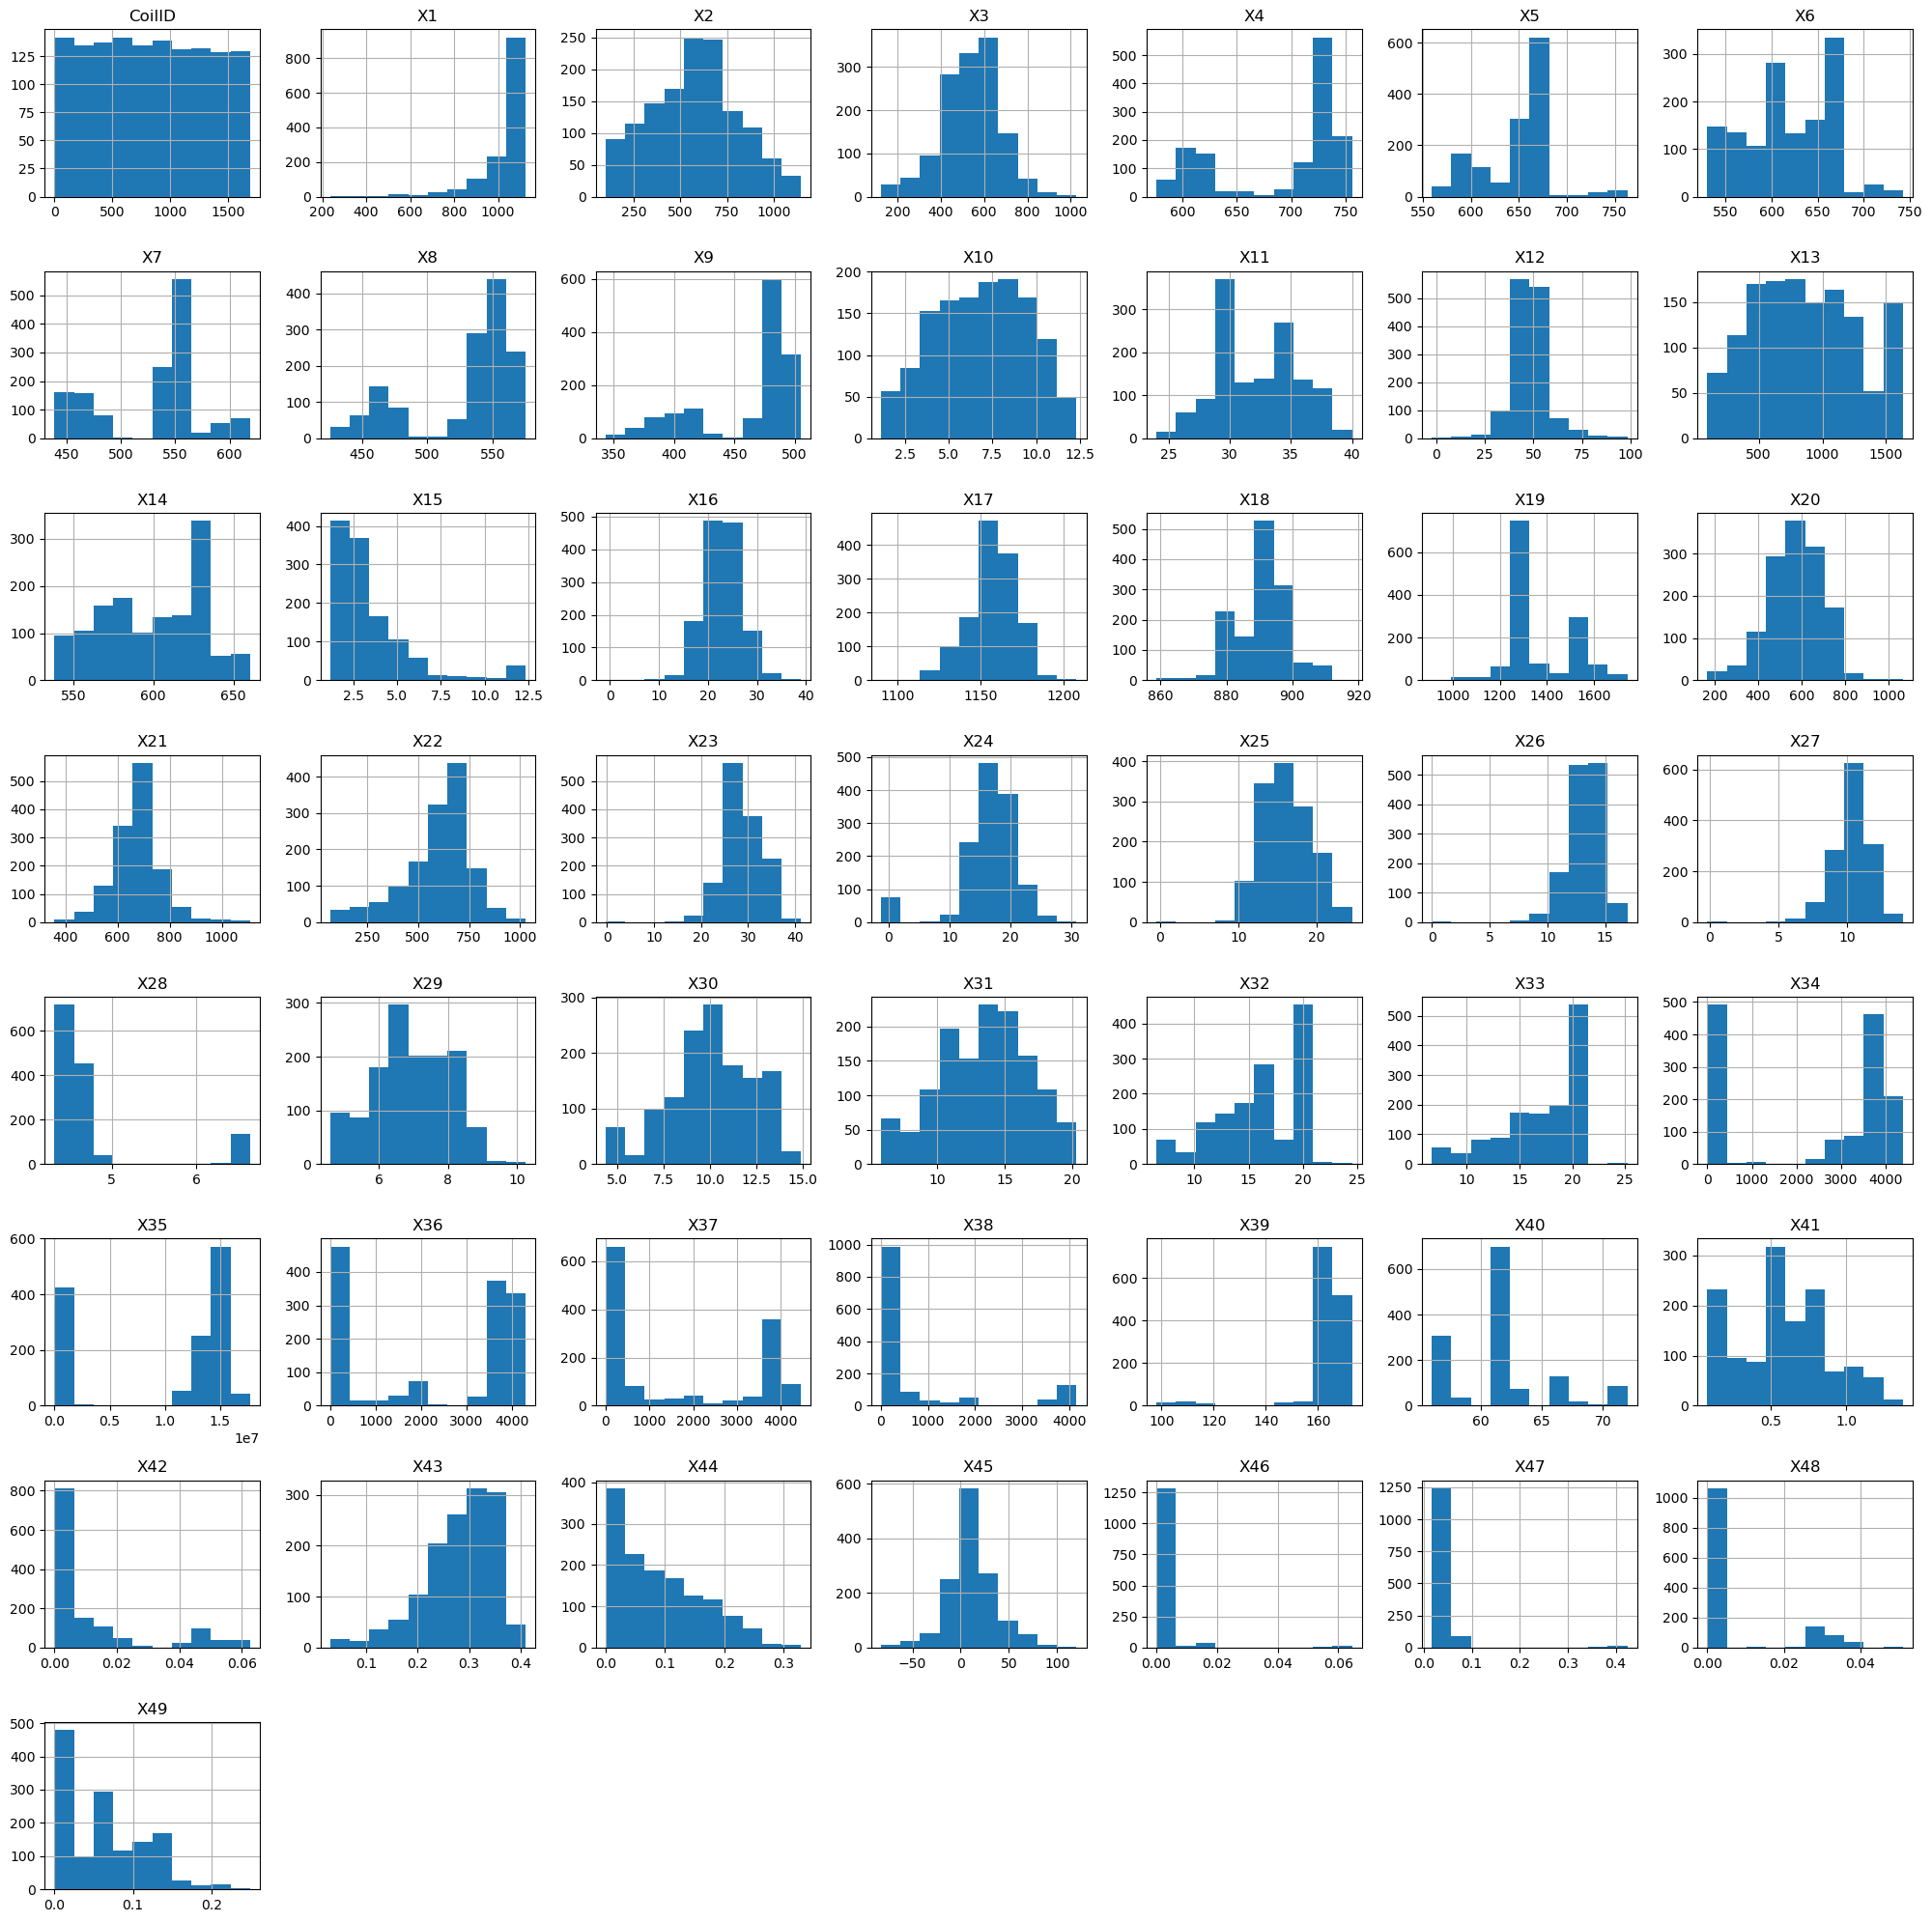

In [92]:
# histrogram
eda.plot_histograms()

# Distrubution Analysis
Key Observation
Features such as X15, X28, X42, X46, X47, and X48 appear highly skewed and may require special attention during preprocessing.
Several features contain extreme values that should be further investigated using boxplots and statistical outlier detection methods.

Features X32 and X33 exhibit moderate negative skewness, while X34, X36, X37, X38 and X35 display bimodal distributions with two distinct peaks. X40 is mutlimodal distribution with many peaks. This suggests the presence of different operating conditions or underlying groups within the manufacturing process. Such features may provide valuable information for defect prediction models.

In [93]:
inspector.summary_stats()

            CoilID           X1           X2           X3           X4  \
count  1352.000000  1352.000000  1352.000000  1352.000000  1352.000000   
mean    833.515533  1028.915322   575.374555   538.372787   692.576938   
std     487.420566   108.505011   232.103882   135.288085    56.798904   
min       1.000000   235.252250    96.755492   124.150450   575.916250   
25%     411.250000  1009.279089   405.533242   441.585514   622.213663   
50%     824.500000  1071.978233   589.160841   548.035306   724.970407   
75%    1254.250000  1092.031100   725.766924   632.238363   734.453213   
max    1691.000000  1124.903234  1148.171484  1026.915778   755.983296   

                X5           X6           X7           X8           X9  ...  \
count  1352.000000  1352.000000  1352.000000  1351.000000  1352.000000  ...   
mean    649.010832   618.584573   529.241056   528.770054   461.699867  ...   
std      35.398207    45.602831    46.263179    40.220201    40.600916  ...   
min     559.27285

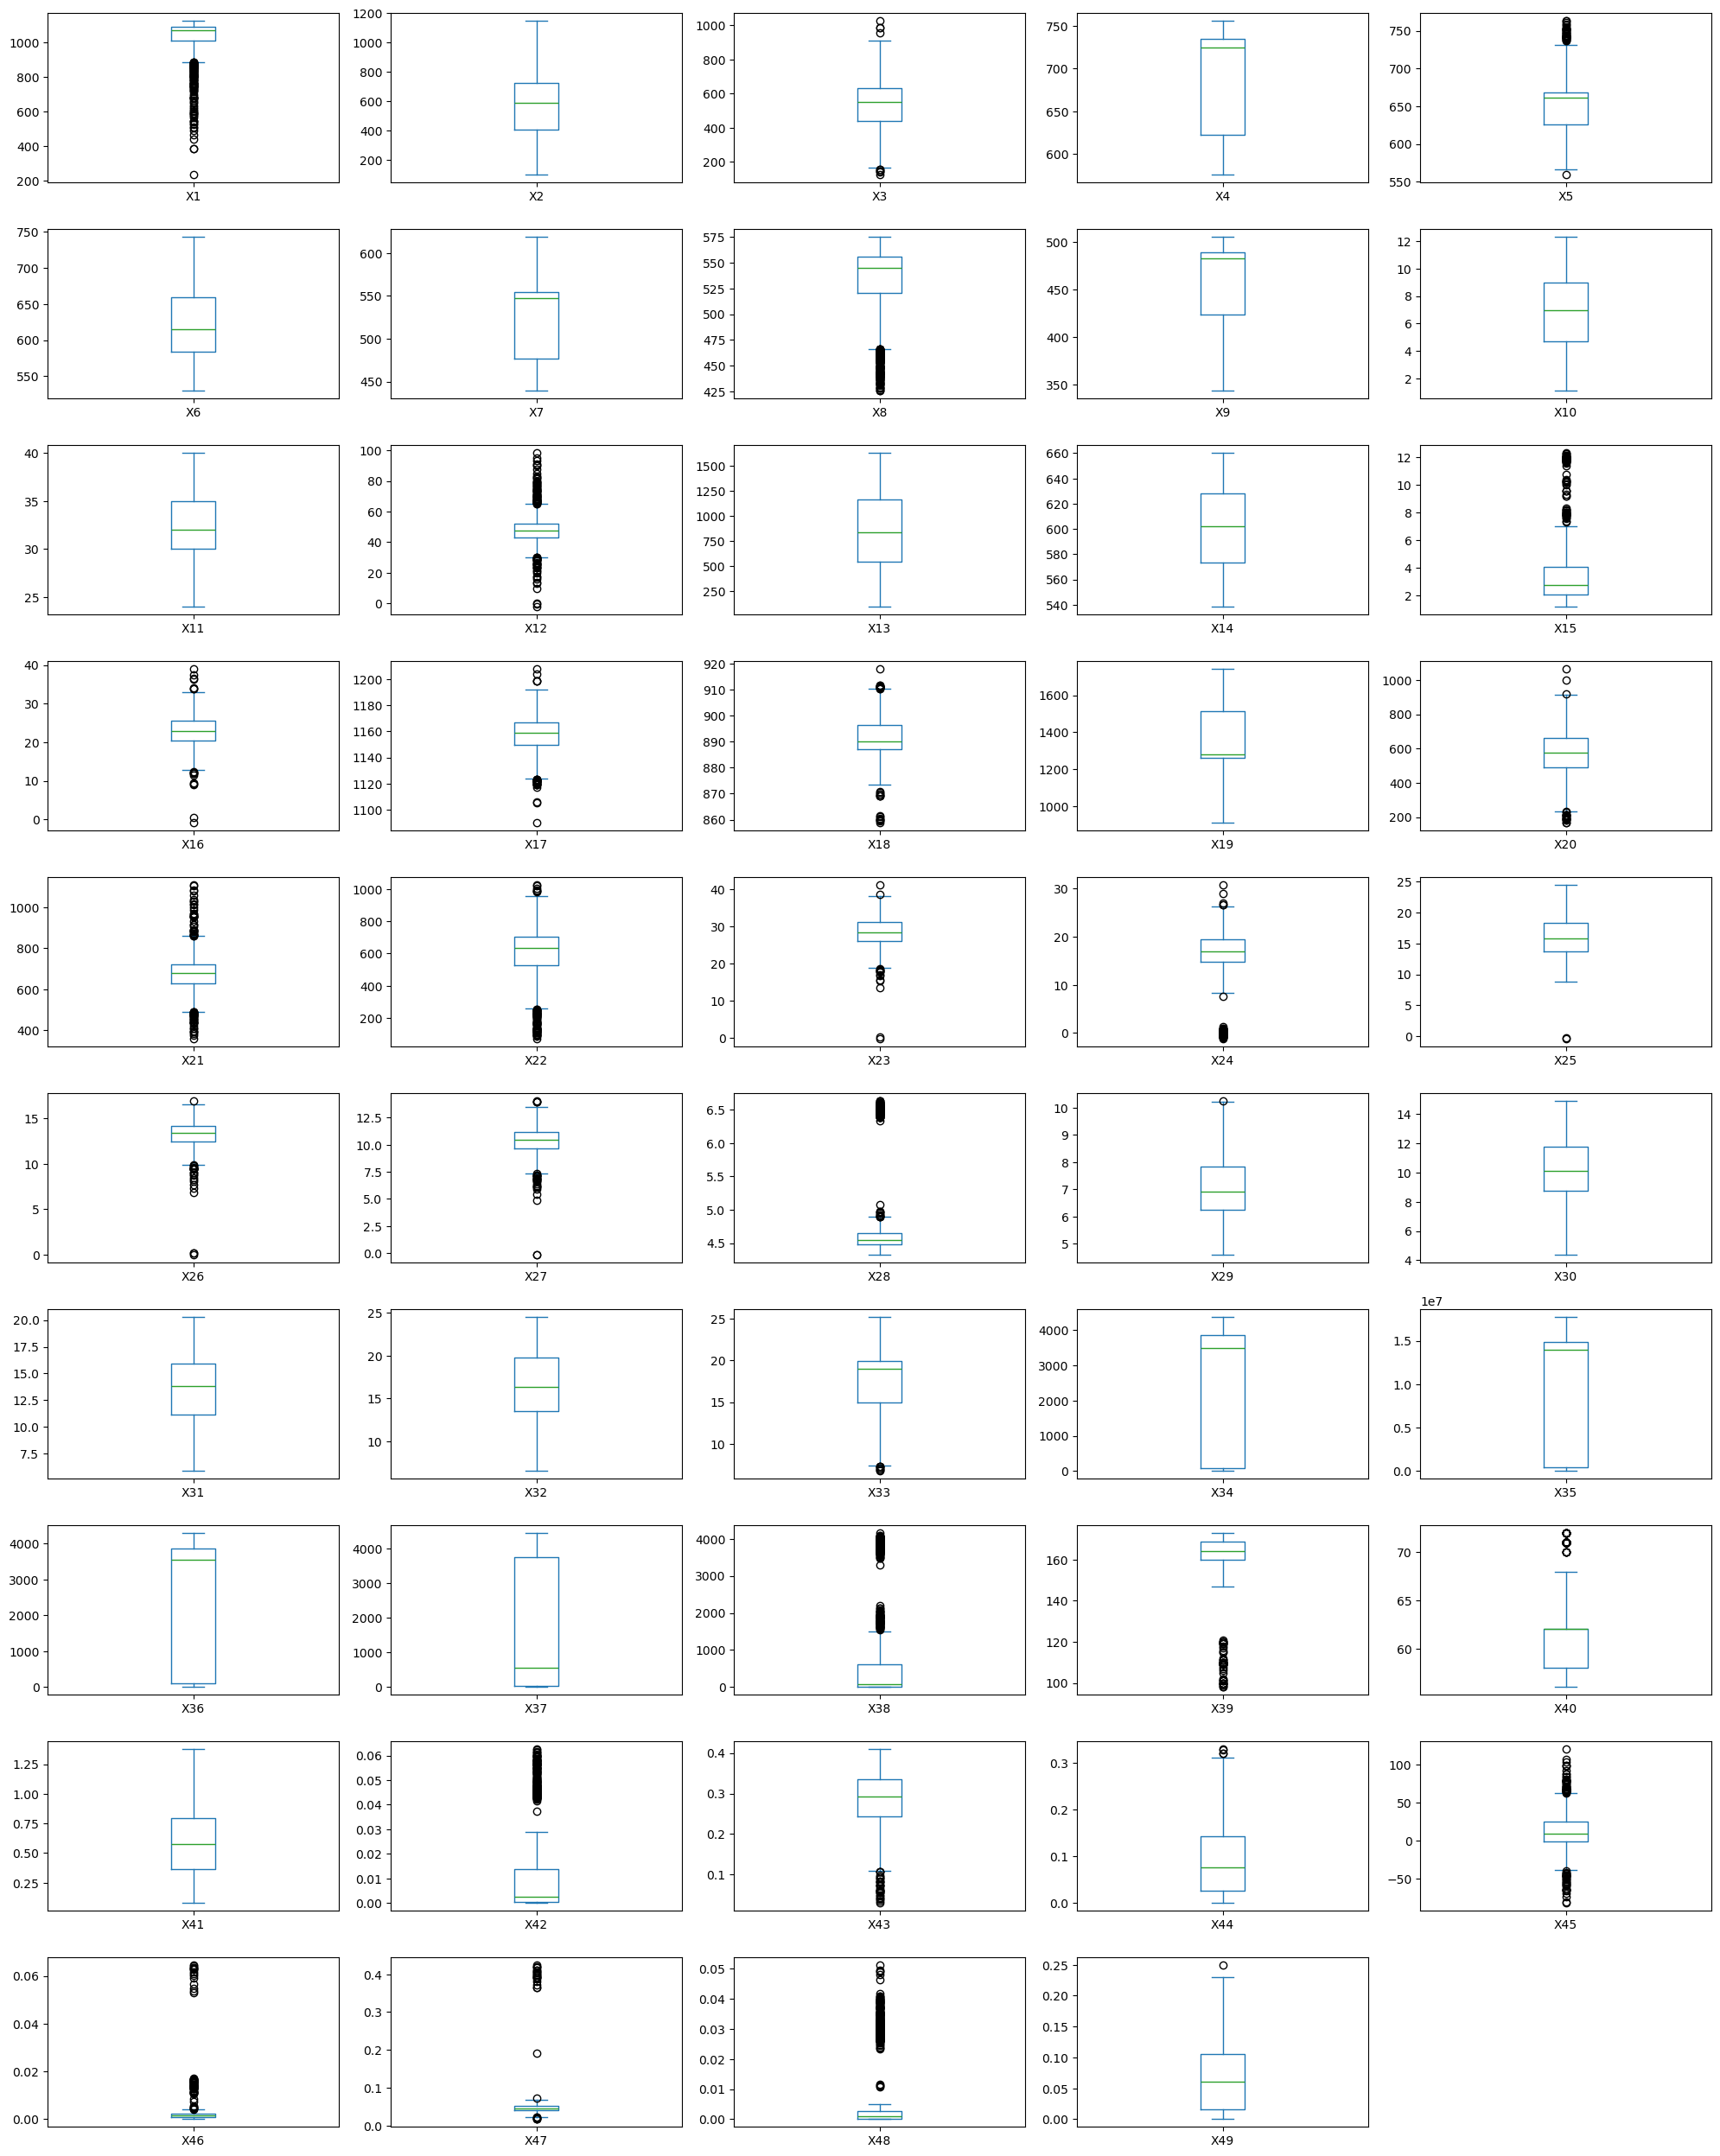

In [85]:
# boxplot
eda.plot_boxplots()

# Outlier Analysis
Key Observations
Boxplots were used to identify potential outliers in the numerical features.
Several variables contain observations beyond the whiskers, indicating the presence of extreme values.
Features X1, X5, X8, X12, X15, X16, X17, X18, X20, X21, X22, X23, X24, X26, X27, X28, X38, X39, X42, X45, X46, X47, and X48 exhibit noticeable outliers.
Features X15, X21, X38, X45, X46, X47, and X48 show a particularly large number of outlier observations.
Some variables such as X34, X35, X36, and X37 display very wide ranges and possible multiple operating regimes, which is consistent with the bimodal distributions observed during histogram analysis.
Since this is a manufacturing defect detection problem, these extreme values may represent important process variations rather than data entry errors. Therefore, outliers should be carefully investigated before removal.

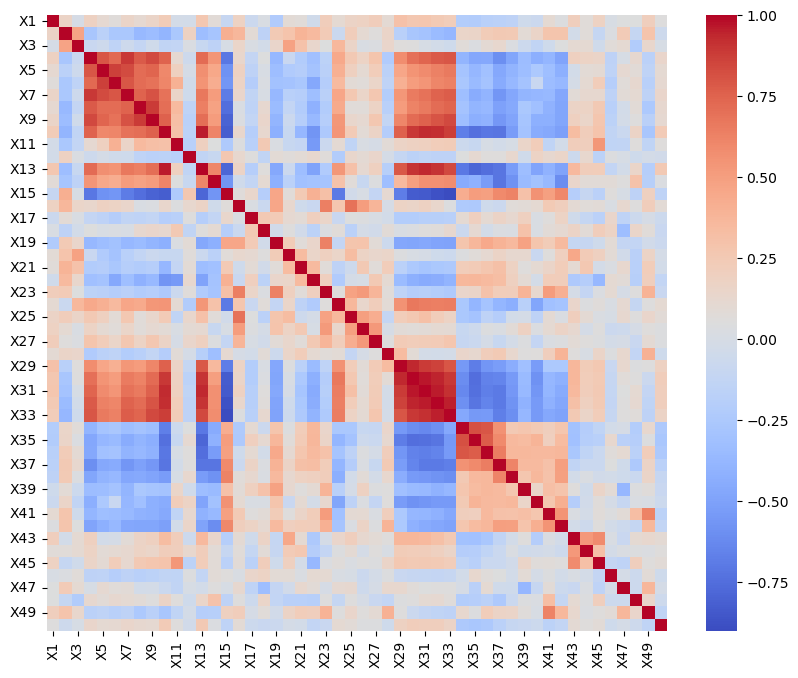

In [86]:
eda.correlation_heatmap()

# Correlation Heatmap Analysis
Note:
• Red shades indicate positive correlations (variables move in the same direction).
• Blue shades indicate negative correlations (variables move in opposite directions).
• Darker colors represent stronger relationships, while lighter colors indicate weaker relationships.

Key Observations
Several groups of features exhibit strong positive correlations, particularly among X4–X9 and X30–X33.
Strong negative correlations are observed between the X30–X33 group and several variables in the X35–X41 range.
Most variables show weak to moderate correlations, indicating that they contribute distinct information.
The presence of highly correlated variables suggests potential multicollinearity, which may affect linear models such as Logistic Regression.
Tree-based models such as XGBoost are generally less sensitive to multicollinearity.

In [98]:
# Class for data preprocessing
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

class DataPreprocessor:
    """
    Performs data preprocessing steps for the Defect Detection dataset.

    Workflow:
    1. Drop unnecessary columns.
    2. Handle missing values.
    3. Treat outliers using IQR capping.
    4. Split features and target.
    5. Create train-validation datasets.
    6. Balance training data using SMOTE.
    """

    def __init__(self):
        """
        Initialize the preprocessor with a copy of the training dataset.
        """
        self.df = data.train_df.copy()

    def drop_col(self):
        """
        Remove irrelevant columns from the dataset.

        Currently removes:
        - CoilID

        Returns:
            self: Enables method chaining.
        """
        self.df = self.df.drop(columns=['CoilID'])
        return self

    def fill_nulls(self):
        """
        Handle missing values in numerical columns.

        Missing values are replaced using the median
        of their respective columns.

        Returns:
            self: Enables method chaining.
        """
        numeric = self.df.select_dtypes(include='number').columns

        for i in numeric:
            self.df[i] = self.df[i].fillna(self.df[i].median())

        return self

    def handle_outliers(self):
        """
        Detect and cap outliers using the IQR method.

        Lower Bound = Q1 - 1.5 * IQR
        Upper Bound = Q3 + 1.5 * IQR

        Values outside these limits are capped
        to the nearest boundary value.

        Target column 'Y' is excluded.

        Returns:
            self: Enables method chaining.
        """
        numeric = self.df.select_dtypes(include='number').columns

        for i in numeric:
            if i != 'Y':

                Q1 = self.df[i].quantile(0.25)
                Q3 = self.df[i].quantile(0.75)

                IQR = Q3 - Q1

                lower_bound = Q1 - 1.5 * IQR
                upper_bound = Q3 + 1.5 * IQR

                self.df[i] = self.df[i].clip(lower_bound, upper_bound)

        return self

    def split_features_target(self):
        """
        Separate independent features and target variable.

        Creates:
        - self.X : Feature matrix
        - self.y : Target column

        Returns:
            self: Enables method chaining.
        """
        self.X = self.df.drop(columns=['Y'])
        self.y = self.df['Y']

        return self

    def train_validation_split(self):
        """
        Split the dataset into training and validation sets.

        Configuration:
        - Test Size: 20%
        - Random State: 42
        - Stratified Split on target variable

        Returns:
            self: Enables method chaining.
        """
        self.X_train, self.X_valid, self.y_train, self.y_valid = train_test_split(self.X, self.y, test_size=0.2, random_state=42, stratify=self.y)
        return self

    def apply_smote(self):
        """
        Apply SMOTE (Synthetic Minority Oversampling Technique)
        to balance the training dataset.

        SMOTE is applied only on the training data
        to prevent data leakage.

        Returns:
            self: Enables method chaining.
        """
        smote = SMOTE(random_state=42)

        self.X_train, self.y_train = smote.fit_resample(self.X_train,self.y_train)

        print('After SMOTE :')
        print('\nX_train shape :', self.X_train.shape)
        print('\ny_train distribution :')
        print(self.y_train.value_counts())

        return self

    def check_shapes(self):
        """
        Display the shapes of the final train and
        validation datasets after preprocessing.

        Returns:
            self: Enables method chaining.
        """
        print('X_train shape :', self.X_train.shape)
        print('X_valid shape :', self.X_valid.shape)
        print('y_train shape :', self.y_train.shape)
        print('y_valid shape :', self.y_valid.shape)

        return self

In [99]:
preprocessor = DataPreprocessor()

preprocessor.drop_col().fill_nulls().handle_outliers().split_features_target().train_validation_split().apply_smote().check_shapes()

After SMOTE :

X_train shape : (2056, 49)

y_train distribution :
Y
0.0    1028
1.0    1028
Name: count, dtype: int64
X_train shape : (2056, 49)
X_valid shape : (271, 49)
y_train shape : (2056,)
y_valid shape : (271,)


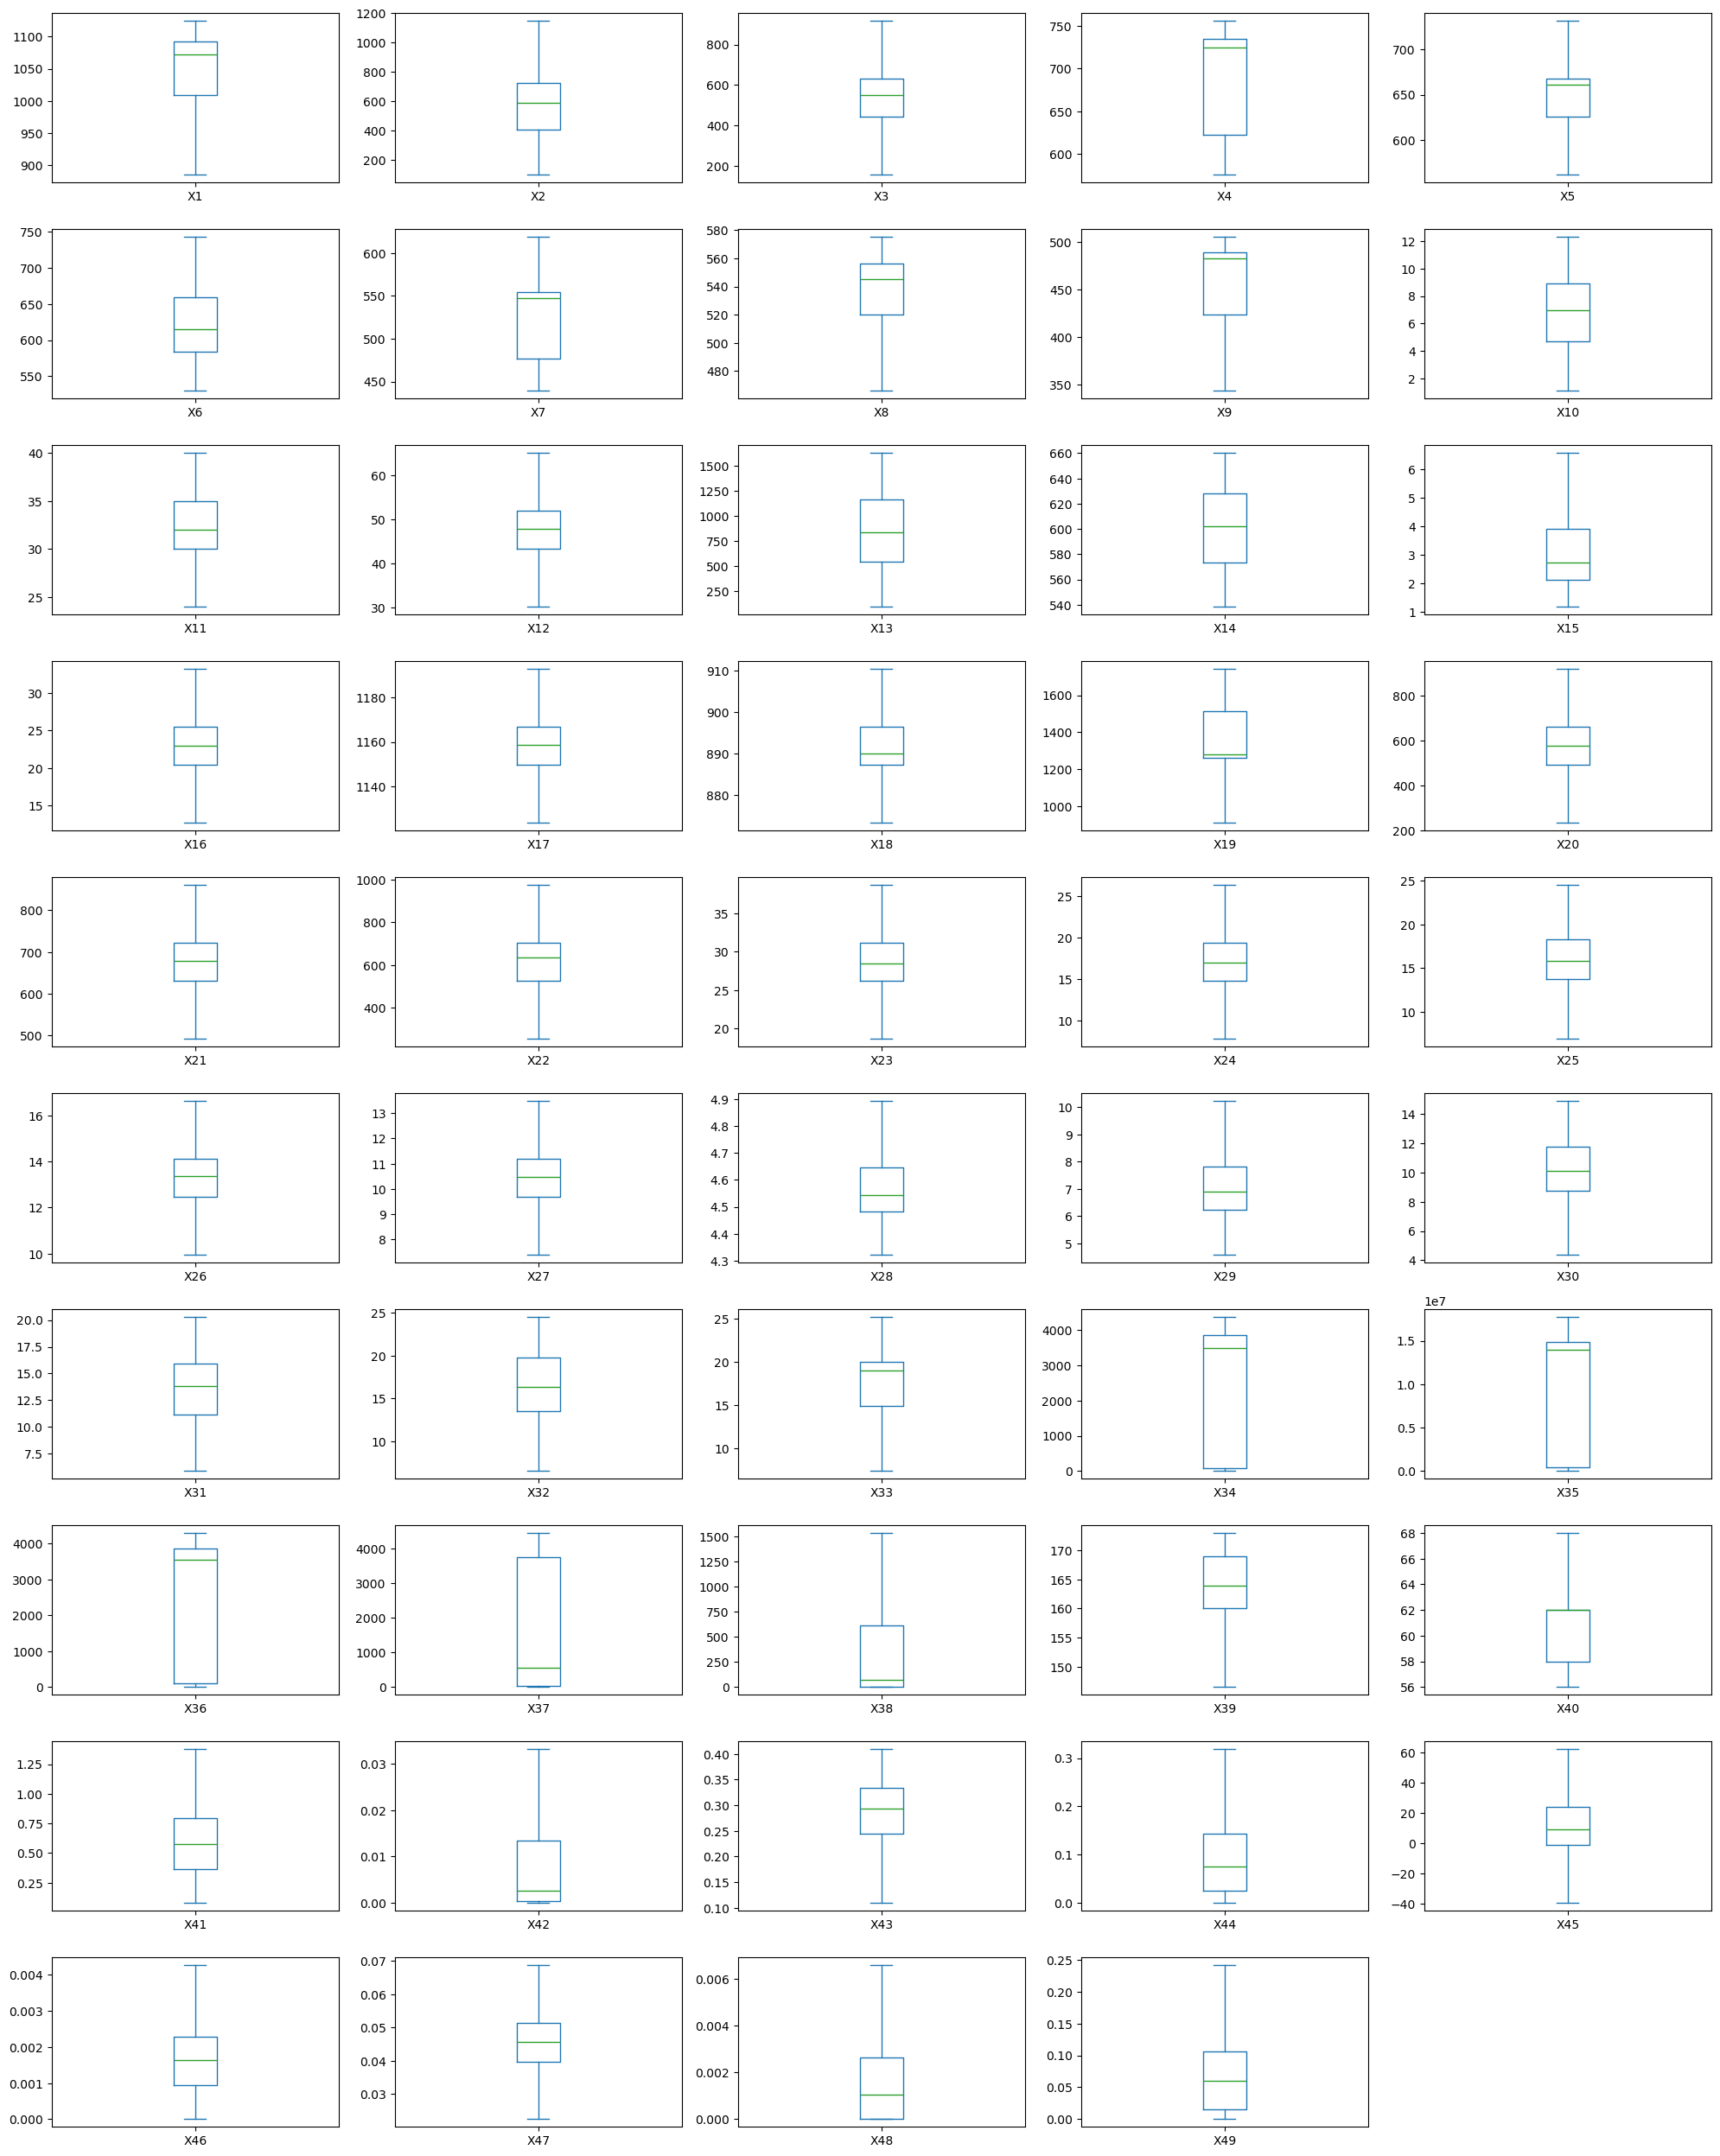

In [100]:
eda.df = preprocessor.df
eda.plot_boxplots()

In [101]:
# Before smote
preprocessor.split_features_target().y.value_counts()

Y
0.0    1286
1.0      66
Name: count, dtype: int64

In [102]:
# After smote
preprocessor.apply_smote().y_train.value_counts()

After SMOTE :

X_train shape : (2056, 49)

y_train distribution :
Y
0.0    1028
1.0    1028
Name: count, dtype: int64


Y
0.0    1028
1.0    1028
Name: count, dtype: int64

In [135]:
# Creating a class for training the models

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
from sklearn.model_selection import RandomizedSearchCV

from xgboost import XGBClassifier


class ModelTrainer:

    def __init__(self):

        # getting preprocessed train-validation data
        self.X_train = preprocessor.X_train
        self.X_valid = preprocessor.X_valid

        self.y_train = preprocessor.y_train
        self.y_valid = preprocessor.y_valid


    # logistic regression baseline model
    def train_logistic_regression(self):

        self.model = LogisticRegression(max_iter=1000, class_weight='balanced')

        self.model.fit(self.X_train, self.y_train)

        return self

    # xgboost model
    def train_xgboost(self):

        # calculating imbalance ratio
        negative_class = (self.y_train == 0).sum()
        positive_class = (self.y_train == 1).sum()

        scale_pos_weight = negative_class / positive_class

        self.model = XGBClassifier(n_estimators=300, max_depth=4,learning_rate=0.05, scale_pos_weight= scale_pos_weight,
            random_state=42, eval_metric='logloss')

        self.model.fit(self.X_train, self.y_train)

        return self

    def train_xgboost_cv(self):
    
         # base model
        negative_class = (self.y_train == 0).sum()
        positive_class = (self.y_train == 1).sum()
        scale_pos_weight = negative_class / positive_class
        xgb_model = XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight= scale_pos_weight)
      
        param_grid = {'n_estimators': [100, 200, 300], 'max_depth': [3, 4, 5, 6], 'learning_rate': [0.01, 0.05, 0.1], 'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]}

        # randomized search
        random_search = RandomizedSearchCV(estimator=xgb_model, param_distributions=param_grid, n_iter=10, scoring='recall',
                                           cv=5, verbose=1, random_state=42, n_jobs=-1)

        # fitting
        random_search.fit(self.X_train, self.y_train)

        # best model
        self.model = random_search.best_estimator_

        print('Best Parameters :')
        print(random_search.best_params_)

        return self

    # prediction
    def predict(self):

        self.y_train_pred = self.model.predict(self.X_train)
        self.y_valid_pred = self.model.predict(self.X_valid) # test

        return self

    # probability prediction
    def predict_probability(self):

        self.y_pred_proba = self.model.predict_proba(self.X_valid)[:,1]

        return self

    # evaluation for both train and test
    def evaluate_model(self):

        print('------TRAIN PERFORMANCE -------\n')

        print('Accuracy :', accuracy_score(self.y_train, self.y_train_pred))

        print('Precision :', precision_score(self.y_train, self.y_train_pred))

        print('Recall :', recall_score(self.y_train, self.y_train_pred))


        print('\n--------VALIDATION PERFORMANCE--------')

        print('Accuracy :', accuracy_score(self.y_valid, self.y_valid_pred))

        print('Precision :', precision_score(self.y_valid, self.y_valid_pred))

        print('Recall :', recall_score(self.y_valid, self.y_valid_pred))

        print('\nConfusion Matrix :')
        print(confusion_matrix(self.y_valid, self.y_valid_pred))

        print('\nClassification Report :')
        print(classification_report(self.y_valid, self.y_valid_pred))

        return self

In [136]:
# logistic model
model_logistic = ModelTrainer()
model_logistic.train_logistic_regression().predict().predict_probability().evaluate_model()

------TRAIN PERFORMANCE -------

Accuracy : 0.7850194552529183
Precision : 0.7606761565836299
Recall : 0.8317120622568094

--------VALIDATION PERFORMANCE--------
Accuracy : 0.7675276752767528
Precision : 0.16216216216216217
Recall : 0.9230769230769231

Confusion Matrix :
[[196  62]
 [  1  12]]

Classification Report :
              precision    recall  f1-score   support

         0.0       0.99      0.76      0.86       258
         1.0       0.16      0.92      0.28        13

    accuracy                           0.77       271
   macro avg       0.58      0.84      0.57       271
weighted avg       0.95      0.77      0.83       271



C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [137]:
print(model_logistic.y_valid_pred.shape)
print(model_logistic.y_pred_proba.shape)

(271,)
(271,)


# Logistic Regression Model Evaluation

Key Observations:

The Logistic Regression model achieved a validation accuracy of 76.75%.
The model shows very high recall for the defect class (Class 1 = 92.31%), meaning it successfully identifies most defective products.
However, the precision for the defect class is only 16.22%, indicating that many non-defective products are incorrectly classified as defective (high false positive rate).
From the confusion matrix, the model correctly detected 12 out of 13 defects, missing only 1 defective sample.
For the non-defective class (Class 0), the model achieved 99% precision and 76% recall, demonstrating reasonable performance on the majority class.

Business Interpretation:

The model is aggressive in detecting defects, which is beneficial when the cost of missing a defective product is high.
However, the large number of false alarms (62 false positives) may increase inspection costs and reduce operational efficiency.
This model is suitable as a baseline model focused on defect detection, but its low precision suggests that further optimization or a more advanced model may be required to reduce false positives while maintaining high defect recall.

Model Behavior:

Training Accuracy: 78.50%
Validation Accuracy: 76.75%

Since the training and validation accuracies are relatively close, there is no significant evidence of overfitting, and the model demonstrates reasonable generalization performance.

Conclusion:

The Logistic Regression model performs well at identifying defective products (high recall) and can serve as a strong baseline model. However, its low precision and high false positive rate indicate room for improvement, making it worthwhile to compare against more advanced models such as XGBoost.

In [121]:
# xga boost
model_xga = ModelTrainer()
model_xga.train_xgboost().predict().predict_probability().evaluate_model()

------TRAIN PERFORMANCE -------

Accuracy : 1.0
Precision : 1.0
Recall : 1.0

--------VALIDATION PERFORMANCE--------
Accuracy : 0.9446494464944649
Precision : 0.375
Recall : 0.23076923076923078

Confusion Matrix :
[[253   5]
 [ 10   3]]

Classification Report :
              precision    recall  f1-score   support

         0.0       0.96      0.98      0.97       258
         1.0       0.38      0.23      0.29        13

    accuracy                           0.94       271
   macro avg       0.67      0.61      0.63       271
weighted avg       0.93      0.94      0.94       271



# Evaluation Notes
Logistic Regression performed better for defect detection, achieving a recall of 92.31% compared to 23.08% for XGBoost. XGBoost model correctly indenftified only 23% of the defective products. Since minimizing missed defects is the key business objective, Logistic Regression is the preferred model.

In [122]:
# xga boost with grid search
model_xga_cv = ModelTrainer()
model_xga_cv.train_xgboost_cv().predict().predict_probability().evaluate_model()

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters :
{'subsample': 1.0, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
------TRAIN PERFORMANCE -------

Accuracy : 1.0
Precision : 1.0
Recall : 1.0

--------VALIDATION PERFORMANCE--------
Accuracy : 0.9446494464944649
Precision : 0.4
Recall : 0.3076923076923077

Confusion Matrix :
[[252   6]
 [  9   4]]

Classification Report :
              precision    recall  f1-score   support

         0.0       0.97      0.98      0.97       258
         1.0       0.40      0.31      0.35        13

    accuracy                           0.94       271
   macro avg       0.68      0.64      0.66       271
weighted avg       0.94      0.94      0.94       271



# Evaluation Notes
Hyperparameter tuning using RandomizedSearchCV improved the XGBoost model's defect detection performance, increasing recall from 23.1% to 30.8%. However, the model still missed 9 out of 13 defective coils. Logistic Regression remained the best-performing model for defect detection, achieving a recall of 92.3% and correctly identifying 12 out of 13 defective coils. Therefore, Logistic Regression is recommended as the final model since minimizing missed defects is the primary business objective.

In [142]:
# Creating a visualization class to plot ROC Curve,
# Precision-Recall Curve, and Confusion Matrix Heatmapfor evaluating classification model performance.

from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

class ModelVisualizer:
    """
    Visualize classification model performance using
    ROC Curve, Precision-Recall Curve, and Confusion Matrix Heatmap.

    Parameters:
        model : Trained ModelTrainer object

    Uses:
        - model.y_valid
        - model.y_pred
        - model.y_pred_proba
    """

    def __init__(self, model):
        """
        Initialize visualizer with trained model outputs.

        Stores:
        - self.y_valid : Actual validation labels
        - self.y_pred : Predicted class labels
        - self.y_pred_proba : Predicted probabilities

        Parameters:
            model : Trained ModelTrainer object
        """

        self.y_valid = model.y_valid
        self.y_pred = model.y_valid_pred
        self.y_pred_proba = model.y_pred_proba
        

    # ROC Curve
    def roc_curve_plot(self):
        """
        Plot ROC Curve and calculate AUC score.

        Helps evaluate how well the model separates
        defective and non-defective coils.

        Returns:
            self : Enables method chaining.
        """

        fpr, tpr, thresholds = roc_curve(self.y_valid, self.y_pred_proba)
        roc_auc = auc(fpr, tpr)

        plt.figure(figsize=(5,3))
        plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
        plt.plot([0,1], [0,1], linestyle='--')

        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')

        plt.title('ROC Curve')
        plt.legend()

        plt.show()

        return self


    # Confusion Matrix Heatmap
    def confusion_matrix_heatmap(self):
        """
        Plot Confusion Matrix as a heatmap.

        Shows:
        - True Positives (TP)
        - True Negatives (TN)
        - False Positives (FP)
        - False Negatives (FN)

        Returns:
            self : Enables method chaining.
        """

        cm = confusion_matrix(self.y_valid, self.y_pred)

        plt.figure(figsize=(6,5))

        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

        plt.xlabel('Predicted')
        plt.ylabel('Actual')

        plt.title('Confusion Matrix Heatmap')

        plt.show()

        return self

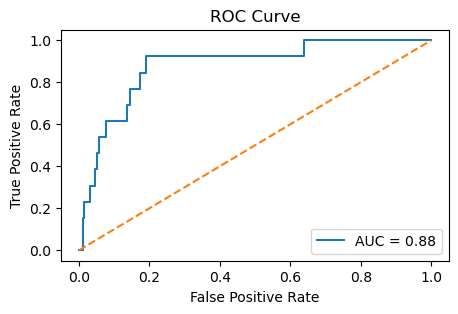

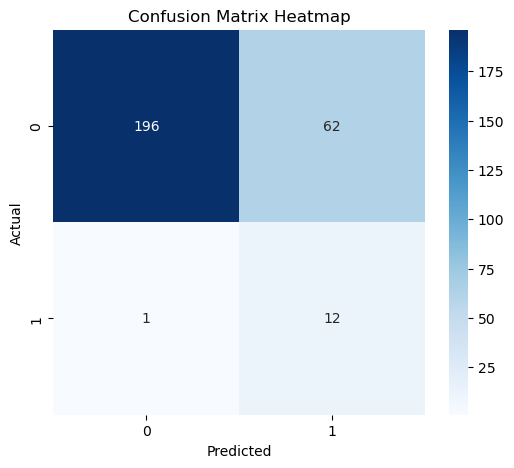

In [144]:
# Object
visualizer = ModelVisualizer(model_logistic)

visualizer.roc_curve_plot().confusion_matrix_heatmap()

# Logistic Regression Model - Visual Evaluation
ROC Curve (AUC = 0.88)

The ROC-AUC score of 0.88 indicates that the model has a strong ability to distinguish between defective and non-defective products. Since the curve is well above the diagonal reference line, the model performs significantly better than random guessing.

Confusion Matrix Analysis
True Negatives (TN): 196 - Correctly identified non-defective products.
False Positives (FP): 62 - Non-defective products incorrectly predicted as defective.
False Negatives (FN): 1 - Only one defective product was missed.
True Positives (TP): 12 - Correctly identified defective products.

Conclusion
The Logistic Regression model successfully identified 12 out of 13 defective products (92.31% recall) while missing only one defect. Although the model generated a higher number of false positives, it demonstrated strong defect detection capability and is suitable for scenarios where detecting defects is more important than reducing false alarms.

In [145]:
import os

os.chdir(r'C:\Users\LENOVO\OneDrive\Desktop\Machine learning\Defect Detection in Hot rolling')

print(os.getcwd())

C:\Users\LENOVO\OneDrive\Desktop\Machine learning\Defect Detection in Hot rolling


In [147]:
# Saving the logistic model

import pickle

with open('logistic_model.pkl', 'wb') as f:
    pickle.dump(model_logistic.model, f)

print('Saved Model to', os.getcwd())

Saved Model to C:\Users\LENOVO\OneDrive\Desktop\Machine learning\Defect Detection in Hot rolling
